Anushka Nanaware Course:MSCS-634-M50 – Advanced Big Data and Data Mining **Assignment:** Lab 1 – Data Visualization, Data Preprocessing, and Statistical Analysis

In [2]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


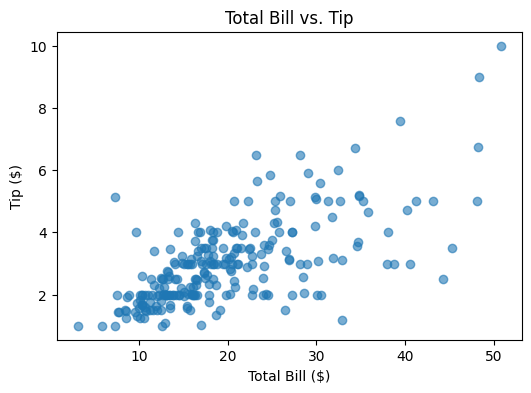

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df['total_bill'], df['tip'], alpha=0.6)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Total Bill vs. Tip')
plt.show()

There's a clear positive relationship between total bill and tip amount - the correlation is about 0.68. As bills get bigger, tips tend to get bigger too, which makes sense since many people tip a rough percentage of the bill rather than a fixed dollar amount. A few high-bill points (around $45–50) also show more scatter, meaning people don't tip as consistently on very large bills.

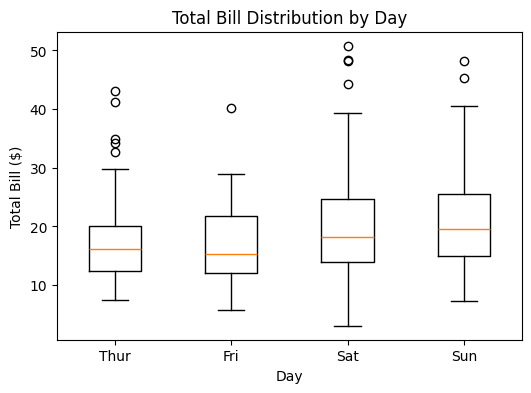

In [4]:
plt.figure(figsize=(6,4))
day_order = ['Thur','Fri','Sat','Sun']
data_by_day = [df[df['day']==d]['total_bill'] for d in day_order]
plt.boxplot(data_by_day, tick_labels=day_order)
plt.xlabel('Day')
plt.ylabel('Total Bill ($)')
plt.title('Total Bill Distribution by Day')
plt.show()

Saturday and Sunday have both higher median bills and more spread than Thursday and Friday - weekend diners are spending more overall. Saturday and Sunday also have the most visible outliers (small circles above the whiskers), including a few bills over $48, meaning there are occasional very large weekend tables or orders. Thursday and Friday look tighter and more consistent, with fewer extreme values.

In [5]:
import numpy as np

np.random.seed(42)
df_missing = df.copy()

total_bill_idx = np.random.choice(df_missing.index, 6, replace=False)
tip_idx = np.random.choice(df_missing.index, 5, replace=False)
size_idx = np.random.choice(df_missing.index, 4, replace=False)

df_missing.loc[total_bill_idx, 'total_bill'] = np.nan
df_missing.loc[tip_idx, 'tip'] = np.nan
df_missing.loc[size_idx, 'size'] = np.nan

# BEFORE: detect and report missing values
print("Missing values per column:")
print(df_missing.isnull().sum())

Missing values per column:
total_bill    6
tip           5
sex           0
smoker        0
day           0
time          0
size          4
dtype: int64


In [6]:
# AFTER: handle missing values using a few different techniques
df_clean = df_missing.copy()

# Mean replacement for total_bill
df_clean['total_bill'] = df_clean['total_bill'].fillna(df_clean['total_bill'].mean())

# Forward fill for tip
df_clean['tip'] = df_clean['tip'].ffill()

# Mode replacement for size
df_clean['size'] = df_clean['size'].fillna(df_clean['size'].mode()[0])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


Insight: I randomly introduced 6 missing values in total_bill, 5 in tip, and 4 in size. I filled total_bill with the column mean (a good default for a fairly normal-looking numeric column), used forward fill for tip (carries the previous customer's tip forward as a placeholder), and filled size with its mode, since party size is a whole number and the most common size makes more sense than an average like 2.3. After cleaning, all missing values are resolved with zero data loss.

In [7]:
# IQR method on total_bill
Q1 = df_clean['total_bill'].quantile(0.25)
Q3 = df_clean['total_bill'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
print(f"Lower bound = {lower_bound:.2f}, Upper bound = {upper_bound:.2f}")

outliers = df_clean[(df_clean['total_bill'] < lower_bound) | (df_clean['total_bill'] > upper_bound)]
print(f"\nNumber of outliers found: {len(outliers)}")
outliers[['total_bill','tip','day']]

Q1 = 13.41, Q3 = 24.02, IQR = 10.61
Lower bound = -2.50, Upper bound = 39.94

Number of outliers found: 10


,total_bill,tip,day
59,48.27,6.73,Sat
95,40.17,4.73,Fri
102,44.30,2.50,Sat
142,41.19,5.00,Thur
156,48.17,5.00,Sun
170,50.81,10.00,Sat
182,45.35,3.50,Sun
184,40.55,3.00,Sun
197,43.11,5.00,Thur
212,48.33,9.00,Sat


In [8]:
# Remove the outliers
df_no_outliers = df_clean[(df_clean['total_bill'] >= lower_bound) & (df_clean['total_bill'] <= upper_bound)]

print("Shape before removing outliers:", df_clean.shape)
print("Shape after removing outliers:", df_no_outliers.shape)

Shape before removing outliers: (244, 7)
Shape after removing outliers: (234, 7)


In [9]:
print("Original shape:", df_no_outliers.shape)

# Sampling by percentage (70% of rows)
df_sampled_pct = df_no_outliers.sample(frac=0.7, random_state=42)
print("Shape after 70% sampling:", df_sampled_pct.shape)

# Sampling by fixed number (100 rows)
df_sampled_n = df_no_outliers.sample(n=100, random_state=42)
print("Shape after sampling 100 rows:", df_sampled_n.shape)

# Dimension elimination - drop a less relevant column
df_reduced_cols = df_no_outliers.drop(columns=['sex'])
print("Columns before:", list(df_no_outliers.columns))
print("Columns after dropping 'sex':", list(df_reduced_cols.columns))

Original shape: (234, 7)
Shape after 70% sampling: (164, 7)
Shape after sampling 100 rows: (100, 7)
Columns before: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
Columns after dropping 'sex': ['total_bill', 'tip', 'smoker', 'day', 'time', 'size']


Insight: I reduced the dataset two ways: row-wise sampling (down to 70% of rows, and separately down to a fixed 100 rows) to demonstrate shrinking dataset size while keeping it representative, and column-wise reduction by dropping sex, since gender isn't especially relevant if our main interest is bill amount and tipping patterns.

In [10]:
df_scale = df_no_outliers.copy()

# Min-Max scaling
df_scale['total_bill_minmax'] = (df_scale['total_bill'] - df_scale['total_bill'].min()) / (df_scale['total_bill'].max() - df_scale['total_bill'].min())

# Z-score standardization
df_scale['total_bill_zscore'] = (df_scale['total_bill'] - df_scale['total_bill'].mean()) / df_scale['total_bill'].std()

# Decimal scaling
max_abs = df_scale['total_bill'].abs().max()
j = len(str(int(max_abs)))
df_scale['total_bill_decimal'] = df_scale['total_bill'] / (10**j)

df_scale[['total_bill','total_bill_minmax','total_bill_zscore','total_bill_decimal']].head(6)

,total_bill,total_bill_minmax,total_bill_zscore,total_bill_decimal
0,16.99,0.382944,-0.241897,0.1699
1,10.34,0.200000,-1.158023,0.1034
2,21.01,0.493535,0.311912,0.2101
3,23.68,0.566988,0.679740,0.2368
4,24.59,0.592022,0.805105,0.2459
5,25.29,0.611279,0.901539,0.2529


In [11]:
# Discretize total_bill into Low / Medium / High categories
df_scale['bill_category'] = pd.cut(df_scale['total_bill'], bins=[0,15,25,100], labels=['Low','Medium','High'])

df_scale[['total_bill','bill_category']].head(10)

,total_bill,bill_category
0,16.990000,Medium
1,10.340000,Low
2,21.010000,Medium
3,23.680000,Medium
4,24.590000,Medium
5,25.290000,High
6,19.822899,Medium
7,26.880000,High
8,15.040000,Medium
9,14.780000,Low


In [12]:
df_scale['bill_category'].value_counts()

,count
bill_category,
Medium,112
Low,78
High,44


Insight: All three scaling methods rescale total_bill differently — Min-Max squeezes everything into 0–1, Z-score centers around 0 in terms of standard deviations, and decimal scaling just shifts the decimal point. For discretization, I split bills into Low (≤$15), Medium ($15–25), and High (>$25) categories — the split came out to 78 Low, 112 Medium, and 44 High, showing most transactions cluster in the mid-range.

In [13]:
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 234 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  234 non-null    float64
 1   tip         234 non-null    float64
 2   sex         234 non-null    object 
 3   smoker      234 non-null    object 
 4   day         234 non-null    object 
 5   time        234 non-null    object 
 6   size        234 non-null    float64
dtypes: float64(3), object(4)
memory usage: 14.6+ KB


In [14]:
df_no_outliers.describe()

,total_bill,tip,size
count,234.000000,234.000000,234.000000
mean,18.745886,2.894402,2.495726
std,7.258822,1.209939,0.899441
min,3.070000,1.000000,1.000000
25%,13.302500,2.000000,2.000000
50%,17.490000,2.750000,2.000000
75%,22.757500,3.500000,3.000000
max,39.420000,7.580000,6.000000


Insight: .info() confirms we have 234 rows (after removing outliers) with no missing values across all 7 columns — 3 numeric (total_bill, tip, size) and 4 categorical. .describe() shows the numeric spread: average bill is about $18.75, average tip about $2.89, and average party size 2.5 people.


In [15]:
print("=== total_bill ===")
print("Min:", df_no_outliers['total_bill'].min())
print("Max:", df_no_outliers['total_bill'].max())
print("Mean:", round(df_no_outliers['total_bill'].mean(), 2))
print("Median:", df_no_outliers['total_bill'].median())
print("Mode:", df_no_outliers['total_bill'].mode()[0])

=== total_bill ===
Min: 3.07
Max: 39.42
Mean: 18.75
Median: 17.490000000000002
Mode: 19.822899159663866


In [16]:
print("=== tip ===")
print("Min:", df_no_outliers['tip'].min())
print("Max:", df_no_outliers['tip'].max())
print("Mean:", round(df_no_outliers['tip'].mean(), 2))
print("Median:", df_no_outliers['tip'].median())
print("Mode:", df_no_outliers['tip'].mode()[0])

=== tip ===
Min: 1.0
Max: 7.58
Mean: 2.89
Median: 2.75
Mode: 2.0


Insight: For total_bill: min $3.07, max $39.42, mean $18.75, median $17.49. The mean sits a bit above the median, meaning the distribution still leans slightly right even after removing the biggest outliers.  For tip: values range from $1.00 to $7.58, with a mean of $2.89 and median of $2.75, showing a fairly tight, only slightly skewed distribution.

In [17]:
range_val = df_no_outliers['total_bill'].max() - df_no_outliers['total_bill'].min()
q1 = df_no_outliers['total_bill'].quantile(0.25)
q3 = df_no_outliers['total_bill'].quantile(0.75)
iqr = q3 - q1
variance = df_no_outliers['total_bill'].var()
std_dev = df_no_outliers['total_bill'].std()

print("Range:", round(range_val, 2))
print("Q1:", q1, "  Q3:", q3, "  IQR:", round(iqr, 2))
print("Variance:", round(variance, 2))
print("Standard Deviation:", round(std_dev, 2))

Range: 36.35
Q1: 13.302499999999998   Q3: 22.7575   IQR: 9.46
Variance: 52.69
Standard Deviation: 7.26


Insight: total_bill has a range of $36.35 (from $3.07 to $39.42), with Q1 = $13.30 and Q3 = $22.76, giving an IQR of $9.46 — this tells us the middle 50% of bills span a fairly moderate $9.46 window. The standard deviation of $7.26 (variance ≈ 52.69) shows a reasonable, not extreme, amount of spread now that we've already removed the outliers in Step 3.

In [18]:
correlation_matrix = df_no_outliers[['total_bill','tip','size']].corr()
correlation_matrix

,total_bill,tip,size
total_bill,1.000000,0.618023,0.571247
tip,0.618023,1.000000,0.472931
size,0.571247,0.472931,1.000000


Insight: total_bill and tip correlate at 0.618 - a moderately strong positive relationship, slightly weaker than the 0.676 we saw back in Step 2 before removing outliers (makes sense, since those large-bill outliers were adding extra pull to that relationship). total_bill and size correlate at 0.571, and tip and size at 0.473 - meaning bigger parties tend to run up bigger bills and slightly bigger tips, though the effect is more moderate than the bill-tip relationship itself.